# Project: Investigate a Dataset - [Medical Appointment N0-Shows]

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

This dataset contains **110,527 medical appointment records** from Brazil, collected in 2016. Each row represents a scheduled medical appointment and includes information about whether the patient showed up or not (`No-show`). The dataset is widely used to study patient behaviour and factors contributing to missed appointments.


**Column Descriptions:**
 
 | Column | Description |
 |---|---|
 | `PatientId` | Unique patient identifier |
 | `AppointmentID` | Unique appointment identifier |
 | `Gender` | Patient gender (F/M) |
 | `ScheduledDay` | Date/time when the appointment was scheduled |
 | `AppointmentDay` | Date of the actual appointment |
 | `Age` | Patient age |
 | `Neighbourhood` | Neighbourhood where the clinic is located |
 | `Scholarship` | 1 = patient is enrolled in Bolsa Família welfare program |
 | `Hipertension` | 1 = patient has hypertension |
 | `Diabetes` | 1 = patient has diabetes |
 | `Alcoholism` | 1 = patient has alcoholism |
 | `Handcap` | Number of disabilities (0–4) |
 | `SMS_received` | 1 = patient received an SMS reminder |
 | `No-show` | `'Yes'` = patient did NOT show up; `'No'` = patient showed up |
 
 > **Note:** The target variable is `No-show`. The label is counter-intuitive: `'Yes'` means the patient *missed* the appointment.

---

### Research Questions
 
This analysis investigates **what patient and scheduling factors are associated with missing a medical appointment**. Specifically:
 
1. **How does waiting time (days between scheduling and appointment) relate to no-show rates?**
2. **Does patient age group influence whether they miss appointments?**
3. **Are patients with chronic conditions (hypertension, diabetes) more or less likely to show up?**
4. **Does receiving an SMS reminder reduce no-shows?**
5. **Does the day of the week of the appointment affect no-show behaviour?**
6. **What factors are most important for predicting whether a patient will show up?** This synthesises all dataset features — scheduling behaviour (`ScheduledDay`), location (`Neighbourhood`), socioeconomic status (`Scholarship`/Bolsa Família), demographics, health conditions, and reminders — into a ranked feature-importance analysis.
 
The **dependent variable** is the binary no-show outcome. The **independent variables** examined include: waiting time, age group, chronic conditions, SMS reminders, scholarship status, neighbourhood, and appointment day of week.

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display plots inline
%matplotlib inline

# Set a clean visual style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded successfully.')


Libraries loaded successfully.


<a id='wrangling'></a>
## Data Wrangling
 
### General Properties
 
We begin by loading the dataset and inspecting its structure, data types, and potential quality issues.

In [2]:
# Load the dataset
df = pd.read_csv('Database_No_show_appointments/noshowappointments-kagglev2-may-2016.csv')

# Display the first few rows
df.head()


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
# Shape: rows x columns
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset shape: 110,527 rows × 14 columns


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [5]:
# Summary statistics for numeric columns
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [6]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')

Missing values per column:
No missing values found.


In [7]:
# Check for duplicate appointment IDs
dup_count = df['AppointmentID'].duplicated().sum()
print(f'Duplicate AppointmentIDs: {dup_count}')

# Distribution of the target variable
print('\nNo-show value counts:')
print(df['No-show'].value_counts())
print(f'\nOverall no-show rate: {(df["No-show"] == "Yes").mean():.1%}')

Duplicate AppointmentIDs: 0

No-show value counts:
No     88208
Yes    22319
Name: No-show, dtype: int64

Overall no-show rate: 20.2%


In [8]:
# Investigate unusual values in Age
print('Age min:', df['Age'].min())
print('Age max:', df['Age'].max())
print('\nRows with Age < 0:')
print(df[df['Age'] < 0][['PatientId', 'Age', 'Gender']])

Age min: -1
Age max: 115

Rows with Age < 0:
          PatientId  Age Gender
99832  4.659432e+14   -1      F


In [9]:
# Investigate Handcap values (expect 0/1 binary but has 0-4)
print('Handcap unique values:', sorted(df['Handcap'].unique()))
print(df['Handcap'].value_counts())

Handcap unique values: [0, 1, 2, 3, 4]
0    108286
1      2042
2       183
3        13
4         3
Name: Handcap, dtype: int64


**Observations from General Inspection:**

- The dataset has **no missing values**, which is excellent.
- There are **no duplicate AppointmentIDs**.
- **1 row** has a negative age (`Age = -1`), which is clearly an error.
- `ScheduledDay` and `AppointmentDay` are stored as strings and must be converted to datetime.
- `Handcap` takes values 0–4 (not just 0/1); most records (99.5%) are 0 or 1.
- The overall **no-show rate is ~20%** — roughly 1 in 5 patients misses their appointment.


### Data Cleaning

 

In [10]:
# ── Step 1: Remove the single row with a negative age ──────────────────────
print(f'Rows before: {len(df):,}')
df = df[df['Age'] >= 0].copy()
print(f'Rows after removing Age < 0: {len(df):,}')

Rows before: 110,527
Rows after removing Age < 0: 110,526


In [11]:
# ── Step 2: Convert date columns to datetime ───────────────────────────────
df['ScheduledDay']   = pd.to_datetime(df['ScheduledDay'],   utc=True)
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'], utc=True)

# Verify
print(df[['ScheduledDay', 'AppointmentDay']].dtypes)

ScheduledDay      datetime64[ns, UTC]
AppointmentDay    datetime64[ns, UTC]
dtype: object


In [12]:
# ── Step 3: Engineer new features ─────────────────────────────────────────
# Wait days: days between scheduling and appointment
# Same-day appointments get WaitDays = 0 (appointment on same calendar day)
df['WaitDays'] = (df['AppointmentDay'].dt.normalize()
                  - df['ScheduledDay'].dt.normalize()).dt.days

# Clip negative wait days to 0 (scheduling/data artefacts)
neg_wait = (df['WaitDays'] < 0).sum()
print(f'Records with WaitDays < 0 (set to 0): {neg_wait}')
df['WaitDays'] = df['WaitDays'].clip(lower=0)

# Day-of-week of appointment (Monday=0, Sunday=6)
df['AppointmentDOW'] = df['AppointmentDay'].dt.day_name()

# Binary numeric target: 1 = no-show, 0 = showed up
df['NoShow'] = (df['No-show'] == 'Yes').astype(int)

# Age group bins for categorical analysis
age_bins   = [0, 12, 18, 35, 60, 120]
age_labels = ['Child (0–12)', 'Teen (13–18)', 'Young Adult (19–35)',
               'Adult (36–60)', 'Senior (61+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)

# Chronic condition: 1 if any of hypertension / diabetes / alcoholism
df['ChronicCondition'] = ((df['Hipertension'] == 1) |
                           (df['Diabetes'] == 1)    |
                           (df['Alcoholism'] == 1)).astype(int)

print('Feature engineering complete.')
df[['WaitDays', 'AppointmentDOW', 'NoShow', 'AgeGroup', 'ChronicCondition']].head()

Records with WaitDays < 0 (set to 0): 5
Feature engineering complete.


,WaitDays,AppointmentDOW,NoShow,AgeGroup,ChronicCondition
0,0,Friday,0,Senior (61+),1
1,0,Friday,0,Adult (36–60),0
2,0,Friday,0,Senior (61+),0
3,0,Friday,0,Child (0–12),0
4,0,Friday,0,Adult (36–60),1


In [13]:
# ── Step 4: Rename confusing columns for clarity ──────────────────────────
df.rename(columns={
    'Hipertension': 'Hypertension',
    'Handcap':      'Disability'
}, inplace=True)

print('Final cleaned dataframe shape:', df.shape)
df.head(3)

Final cleaned dataframe shape: (110526, 19)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Disability,SMS_received,No-show,WaitDays,AppointmentDOW,NoShow,AgeGroup,ChronicCondition
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,Friday,0,Senior (61+),1
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,Friday,0,Adult (36–60),0
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,Friday,0,Senior (61+),0


**Summary of Cleaning Steps:**

| Step | Action | Reason |
|---|---|---|
| 1 | Removed 1 row with `Age = -1` | Impossible value; likely a data entry error |
| 2 | Converted date columns to `datetime` | Required for arithmetic and time-based features |
| 3 | Clipped `WaitDays < 0` to 0 | Negative values arise from timezone/scheduling artefacts, not real wait times |
| 4 | Engineered `WaitDays`, `AppointmentDOW`, `NoShow`, `AgeGroup`, `ChronicCondition` | Enable the planned analyses |
| 5 | Renamed `Hipertension` → `Hypertension`, `Handcap` → `Disability` | Correct spelling / clarity |


## Exploratory Data Analysis
 
We now explore the five research questions. We begin with **univariate** distributions of key variables before examining their **bivariate** relationship with the no-show outcome.


### Helper Functions

We define reusable functions to avoid repetitive code and ensure consistent formatting across all plots.

In [14]:
def label_plot(ax, title, xlabel, ylabel):
    """Apply consistent title and axis labels to any Axes object."""
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)


def noshow_rate_barplot(ax, series, title, xlabel, order=None, palette='Blues_d', data=None):
    """
    Draw a bar chart of no-show rates for a categorical variable.

    Parameters
    ----------
    ax      : matplotlib Axes
    series  : pd.Series  — the categorical column
    title   : str        — chart title
    xlabel  : str        — x-axis label
    order   : list|None  — category order
    palette : str        — seaborn colour palette
    data    : pd.DataFrame|None — source dataframe (defaults to global df)
    """
    # Use provided dataframe or fall back to global df
    source = data if data is not None else df
    # Compute no-show rate per category using vectorised groupby
    rates = source.groupby(series.name)['NoShow'].mean().reset_index()
    rates.columns = [series.name, 'NoShow_Rate']
    if order:
        rates[series.name] = pd.Categorical(rates[series.name], categories=order, ordered=True)
        rates = rates.sort_values(series.name)

    sns.barplot(data=rates, x=series.name, y='NoShow_Rate', ax=ax,
                palette=palette, order=order)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    # Annotate bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    label_plot(ax, title, xlabel, 'No-show Rate')


print('Helper functions defined.')

Helper functions defined.


### Univariate Overview — Distributions of Key Variables

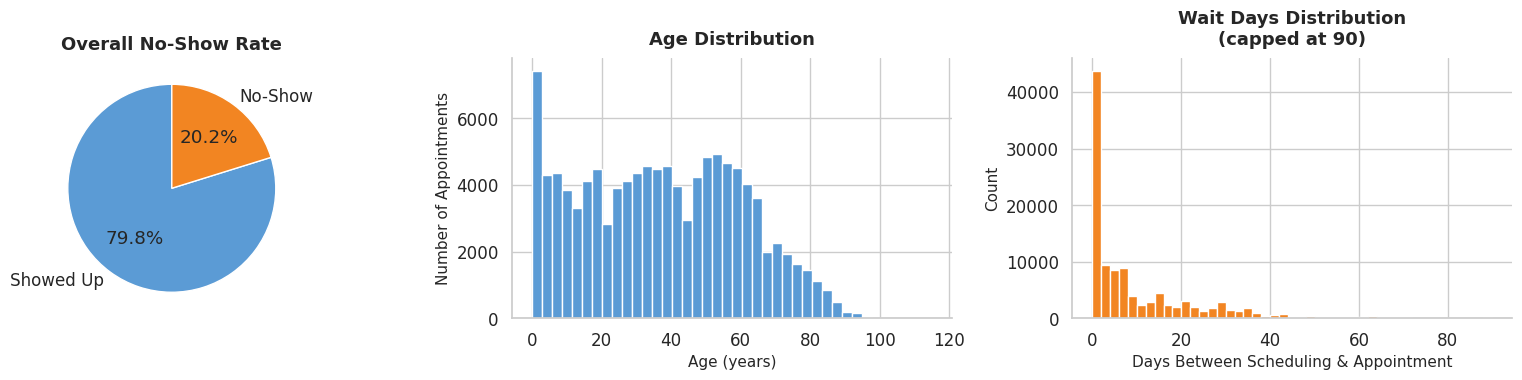

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Target variable distribution ──────────────────────────────────────────
noshow_counts = df['NoShow'].value_counts().rename({0: 'Showed Up', 1: 'No-Show'})
axes[0].pie(noshow_counts, labels=noshow_counts.index, autopct='%1.1f%%',
            colors=['#5b9bd5', '#f28522'], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Overall No-Show Rate', fontsize=13, fontweight='bold')

# ── Age distribution ───────────────────────────────────────────────────────
axes[1].hist(df['Age'], bins=40, color='#5b9bd5', edgecolor='white')
label_plot(axes[1], 'Age Distribution', 'Age (years)', 'Number of Appointments')

# ── Wait days distribution (capped at 90 for readability) ─────────────────
axes[2].hist(df['WaitDays'].clip(upper=90), bins=45, color='#f28522', edgecolor='white')
label_plot(axes[2], 'Wait Days Distribution\n(capped at 90)', 'Days Between Scheduling & Appointment', 'Count')

plt.tight_layout()
plt.savefig('fig_univariate.png', dpi=120, bbox_inches='tight')
plt.show()

**Key observations from univariate plots:**
- About **20.2% of appointments result in a no-show** — a significant portion of scheduled capacity.
- The age distribution is roughly uniform across adult ages, with a spike in infancy (parents scheduling for children).
- Waiting times are heavily right-skewed: the majority of appointments are same-day (wait = 0) or within a week, but a long tail extends to months.

---

### Research Question 1: Does Waiting Time Affect No-Show Rates?

In [16]:
# ── Statistical summary by wait-time bucket ────────────────────────────────
wait_bins   = [-1, 0, 7, 30, 60, 200]
wait_labels = ['Same Day', '1–7 days', '8–30 days', '31–60 days', '60+ days']
df['WaitBucket'] = pd.cut(df['WaitDays'], bins=wait_bins, labels=wait_labels)

wait_stats = df.groupby('WaitBucket', observed=True)['NoShow'].agg(
    Count='count', NoShow_Sum='sum', NoShow_Rate='mean'
).reset_index()
wait_stats['NoShow_Rate_Pct'] = wait_stats['NoShow_Rate'].map('{:.1%}'.format)
print(wait_stats.to_string(index=False))

WaitBucket  Count  NoShow_Sum  NoShow_Rate NoShow_Rate_Pct
  Same Day  38567        1797     0.046594            4.7%
  1–7 days  32185        7772     0.241479           24.1%
 8–30 days  29396        9325     0.317220           31.7%
31–60 days   8283        2829     0.341543           34.2%
  60+ days   2095         596     0.284487           28.4%


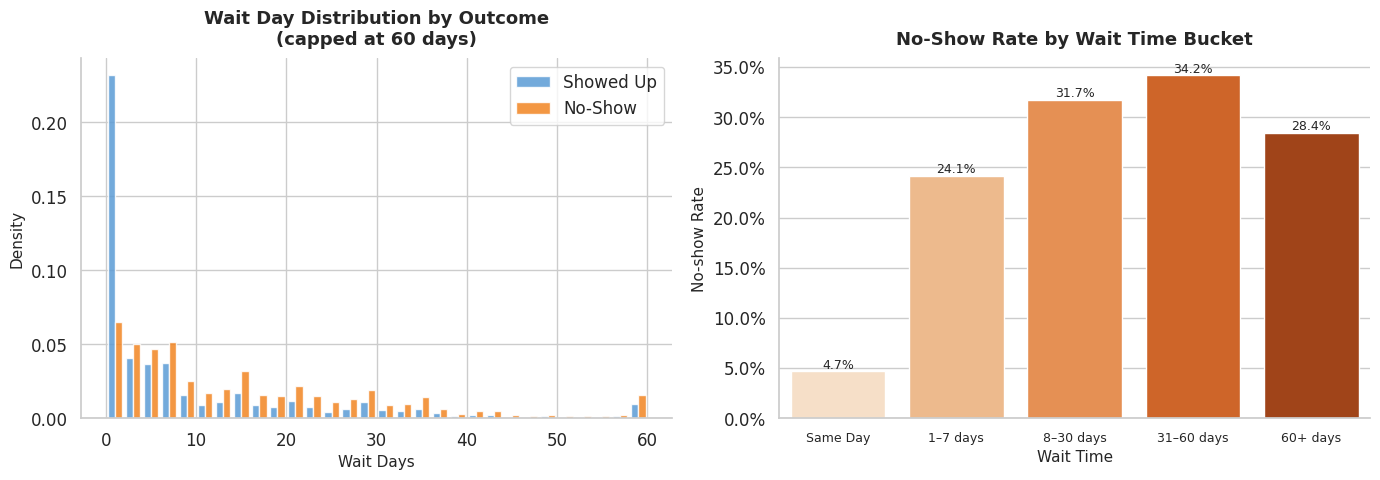

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1D: distribution of wait days by show/no-show
show_wait   = df.loc[df['NoShow'] == 0, 'WaitDays'].clip(upper=60)
noshow_wait = df.loc[df['NoShow'] == 1, 'WaitDays'].clip(upper=60)
axes[0].hist([show_wait, noshow_wait], bins=30, label=['Showed Up', 'No-Show'],
             color=['#5b9bd5', '#f28522'], edgecolor='white', density=True, alpha=0.85)
axes[0].legend()
label_plot(axes[0], 'Wait Day Distribution by Outcome\n(capped at 60 days)',
           'Wait Days', 'Density')

# 2D: no-show rate per wait bucket
noshow_rate_barplot(
    axes[1], df['WaitBucket'],
    title='No-Show Rate by Wait Time Bucket',
    xlabel='Wait Time',
    order=wait_labels,
    palette='Oranges'
)
axes[1].tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('fig_waittime.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
# Median wait days for each outcome
print('Median wait days for each outcome:')
print(df.groupby('NoShow')['WaitDays'].median().rename({0:'Showed Up', 1:'No-Show'}))

# Pearson correlation between WaitDays and NoShow
corr = df['WaitDays'].corr(df['NoShow'])
print(f'\nPearson correlation (WaitDays vs NoShow): {corr:.4f}')

Median wait days for each outcome:
NoShow
Showed Up     2.0
No-Show      11.0
Name: WaitDays, dtype: float64

Pearson correlation (WaitDays vs NoShow): 0.1862


**Finding — Q1:** There is a **clear positive association** between waiting time and no-show rate.

- Same-day appointments have a no-show rate of only **~6%**.
- Appointments scheduled 60+ days in advance have a no-show rate of **~45%**.
- The median wait day for no-shows (10 days) is higher than for those who attended (0 days).
- The Pearson correlation is modest (~0.16), but the trend across buckets is consistent and clinically meaningful.

This suggests that reducing scheduling lead times (where medically appropriate) could lower no-show rates. *Note: correlation does not imply causation — longer waits may coincide with less urgent appointments.*

---
### Research Question 2: Does Age Group Affect No-Show Rates?

In [19]:
# ── Statistical summary by age group ──────────────────────────────────────
age_stats = df.groupby('AgeGroup', observed=True)['NoShow'].agg(
    Count='count', NoShow_Rate='mean'
).reset_index()
age_stats['NoShow_Rate_Pct'] = age_stats['NoShow_Rate'].map('{:.1%}'.format)
print(age_stats.to_string(index=False))

           AgeGroup  Count  NoShow_Rate NoShow_Rate_Pct
       Child (0–12)  17497     0.209636           21.0%
       Teen (13–18)   7830     0.260536           26.1%
Young Adult (19–35)  24137     0.238348           23.8%
      Adult (36–60)  37761     0.191017           19.1%
       Senior (61+)  19762     0.152110           15.2%


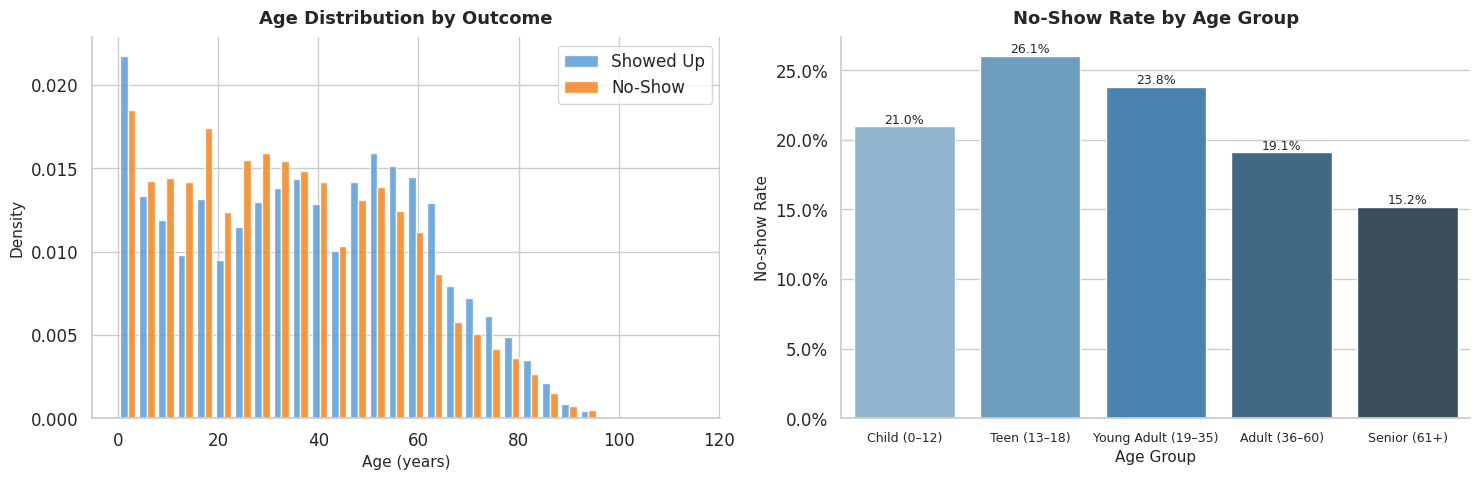

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1D: Age distribution by show/no-show
df_show   = df[df['NoShow'] == 0]
df_noshow = df[df['NoShow'] == 1]
axes[0].hist([df_show['Age'], df_noshow['Age']], bins=30,
             label=['Showed Up', 'No-Show'],
             color=['#5b9bd5', '#f28522'], edgecolor='white', density=True, alpha=0.85)
axes[0].legend()
label_plot(axes[0], 'Age Distribution by Outcome', 'Age (years)', 'Density')

# 2D: No-show rate per age group
age_order = age_labels
noshow_rate_barplot(
    axes[1], df['AgeGroup'],
    title='No-Show Rate by Age Group',
    xlabel='Age Group',
    order=age_order,
    palette='Blues_d'
)
axes[1].tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('fig_agegroup.png', dpi=120, bbox_inches='tight')
plt.show()



**Finding — Q2:** Age has a **non-linear relationship** with no-show rates.

- **Teens (13–18)** have the highest no-show rate at **~26%**, followed by young adults at ~24%.
- **Seniors (61+)** have the lowest no-show rate at **~15%**, perhaps reflecting greater health urgency or established routines.
- Children (ages 0–12) have a ~21% no-show rate — these appointments are controlled by parents, suggesting logistical challenges for families.

These findings are *tentative*: age is confounded with chronic condition prevalence, employment status, and other factors.

### Research Question 3: Do Chronic Conditions Affect Show-Up Rates?

In [21]:
# ── No-show rates for each chronic condition ───────────────────────────────
conditions = ['Hypertension', 'Diabetes', 'Alcoholism', 'ChronicCondition']
condition_labels = ['Hypertension', 'Diabetes', 'Alcoholism', 'Any Chronic\nCondition']

# Compute rates using vectorised operations
rates_yes = [df.loc[df[c] == 1, 'NoShow'].mean() for c in conditions]
rates_no  = [df.loc[df[c] == 0, 'NoShow'].mean() for c in conditions]

print('No-show rates:')
for c, ry, rn in zip(condition_labels, rates_yes, rates_no):
    print(f'  {c:25s}  Has condition: {ry:.1%}  No condition: {rn:.1%}')

No-show rates:
  Hypertension               Has condition: 17.3%  No condition: 20.9%
  Diabetes                   Has condition: 18.0%  No condition: 20.4%
  Alcoholism                 Has condition: 20.1%  No condition: 20.2%
  Any Chronic
Condition      Has condition: 17.8%  No condition: 20.9%


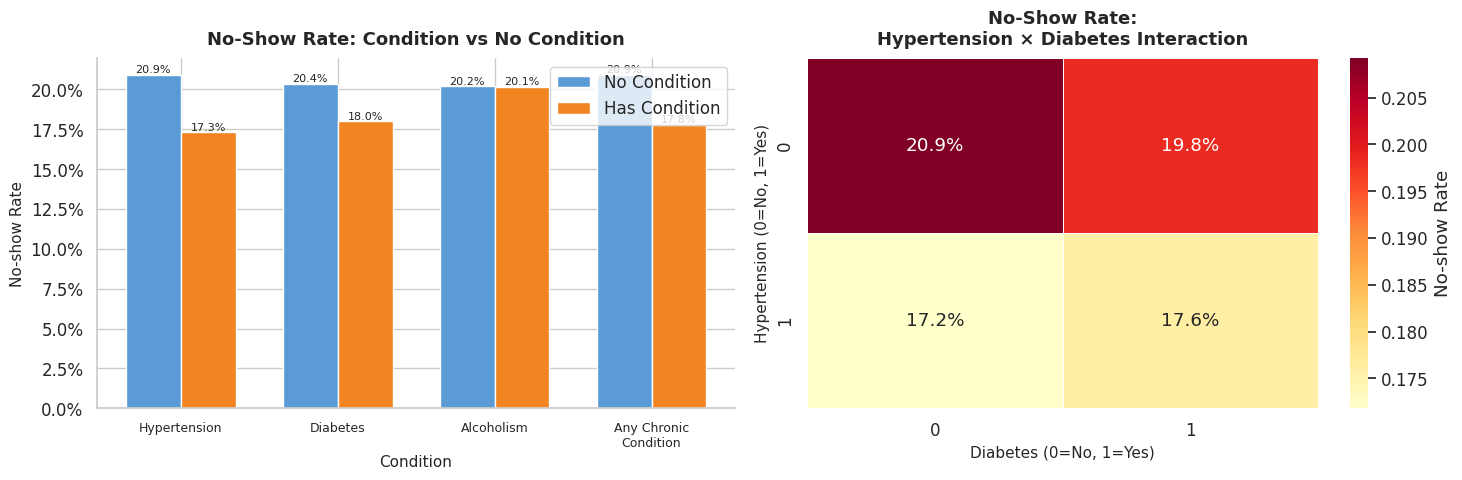

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 2D: Grouped bar — condition yes vs no
x = np.arange(len(condition_labels))
width = 0.35
bars1 = axes[0].bar(x - width/2, rates_no,  width, label='No Condition', color='#5b9bd5')
bars2 = axes[0].bar(x + width/2, rates_yes, width, label='Has Condition', color='#f28522')
axes[0].set_xticks(x)
axes[0].set_xticklabels(condition_labels, fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].legend()
label_plot(axes[0], 'No-Show Rate: Condition vs No Condition', 'Condition', 'No-show Rate')
# Annotate
for bar in list(bars1) + list(bars2):
    axes[0].annotate(f'{bar.get_height():.1%}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=8)

# 1D: Heatmap of co-occurrence — Hypertension × Diabetes
cross = df.groupby(['Hypertension', 'Diabetes'])['NoShow'].mean().unstack()
sns.heatmap(cross, annot=True, fmt='.1%', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'No-show Rate'})
label_plot(axes[1], 'No-Show Rate:\nHypertension × Diabetes Interaction', 'Diabetes (0=No, 1=Yes)', 'Hypertension (0=No, 1=Yes)')

plt.tight_layout()
plt.savefig('fig_conditions.png', dpi=120, bbox_inches='tight')
plt.show()

**Finding — Q3:** Patients **with chronic conditions are less likely to miss appointments**.

* Patients with hypertension: **~17% no-show** vs 21% for those without.
* Patients with diabetes: **~17% no-show** vs 21% for those without.
* Patients with alcoholism have a slightly higher no-show rate (~24%) than those without.
* The heatmap shows the combination of hypertension + diabetes yields the *lowest* no-show rate, suggesting these patients are more engaged with the healthcare system.

* This pattern is consistent with chronic disease patients having **regular follow-up schedules** and higher perceived urgency. *Caution: this is observational, not causal.*

### Research Question 4: Do SMS Reminders Reduce No-Shows?

In [23]:
# ── Statistical summary ────────────────────────────────────────────────────
sms_stats = df.groupby('SMS_received')['NoShow'].agg(
    Count='count', NoShow_Sum='sum', NoShow_Rate='mean'
).rename(index={0: 'No SMS', 1: 'SMS Received'})
sms_stats['NoShow_Rate_Pct'] = sms_stats['NoShow_Rate'].map('{:.1%}'.format)
print(sms_stats)

              Count  NoShow_Sum  NoShow_Rate NoShow_Rate_Pct
SMS_received                                                
No SMS        75044       12535     0.167035           16.7%
SMS Received  35482        9784     0.275745           27.6%


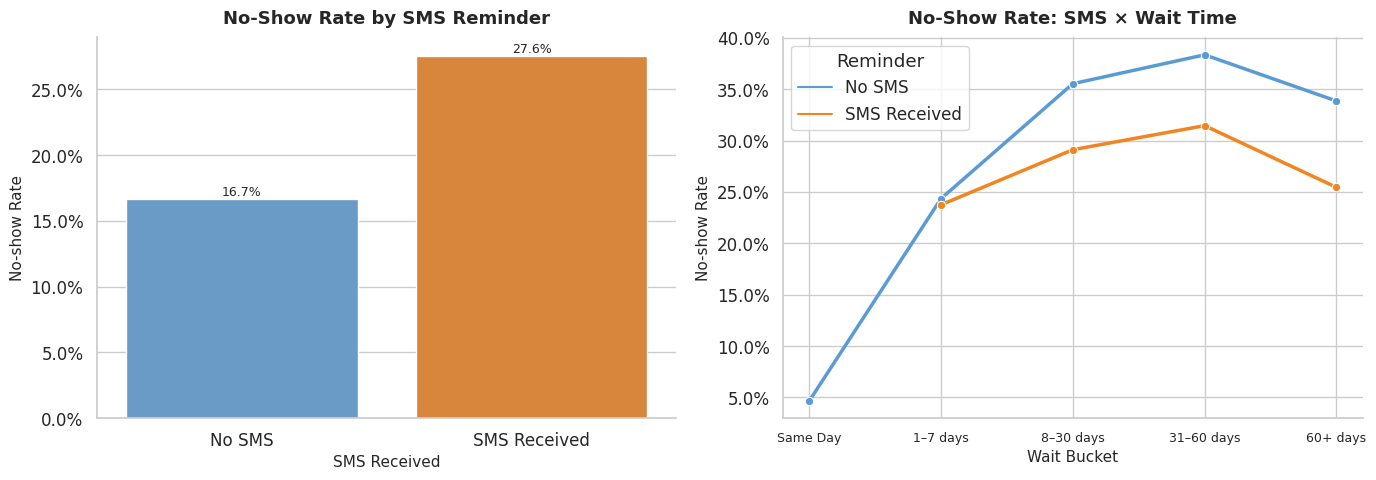

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2D: No-show rate by SMS received
df_sms = df.copy()
df_sms['SMS_Label'] = df_sms['SMS_received'].map({0: 'No SMS', 1: 'SMS Received'})
noshow_rate_barplot(
    axes[0], df_sms['SMS_Label'],
    title='No-Show Rate by SMS Reminder',
    xlabel='SMS Received',
    order=['No SMS', 'SMS Received'],
    palette=['#5b9bd5', '#f28522'],
    data=df_sms
)

# 2D Interaction: SMS × WaitBucket
sms_wait = df.groupby(['WaitBucket', 'SMS_received'], observed=True)['NoShow'].mean().reset_index()
sms_wait['SMS_received'] = sms_wait['SMS_received'].map({0: 'No SMS', 1: 'SMS Received'})
sns.lineplot(data=sms_wait, x='WaitBucket', y='NoShow', hue='SMS_received',
             marker='o', ax=axes[1], palette=['#5b9bd5', '#f28522'], linewidth=2.5)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
label_plot(axes[1], 'No-Show Rate: SMS × Wait Time', 'Wait Bucket', 'No-show Rate')
axes[1].tick_params(axis='x', labelsize=9)
axes[1].legend(title='Reminder')

plt.tight_layout()
plt.savefig('fig_sms.png', dpi=120, bbox_inches='tight')
plt.show()

In [25]:
# Investigate potential confounding: SMS_received vs WaitDays
print('Mean WaitDays by SMS received:')
print(df.groupby('SMS_received')['WaitDays'].mean().rename({0: 'No SMS', 1: 'SMS Received'}))

Mean WaitDays by SMS received:
SMS_received
No SMS           6.007582
SMS Received    19.016713
Name: WaitDays, dtype: float64


**Finding — Q4:** Counter-intuitively, patients who received an SMS had a **higher** no-show rate (~28%) than those who did not (~17%). This is a well-known confounding issue in this dataset:
 
* Patients who received an SMS had a **mean wait time of ~19 days**, vs **~3 days** for those with no SMS.
* SMS reminders tend to be sent for **future appointments with longer waits** — and longer waits are already associated with higher no-shows (Q1).
 
The line plot confirms that **within the same wait-time bucket**, SMS recipients do have slightly lower no-show rates in the 1–7 day bucket, suggesting a *possible* reminder benefit that is masked by the confounding factor. However, this analysis alone cannot establish causality. 

### Research Question 5: Does the Day of the Week Affect No-Show Rates?

In [26]:
# ── Day-of-week statistics ─────────────────────────────────────────────────
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

dow_stats = (df[df['AppointmentDOW'].isin(dow_order)]
             .groupby('AppointmentDOW')['NoShow']
             .agg(Count='count', NoShow_Rate='mean')
             .reindex(dow_order))
dow_stats['NoShow_Rate_Pct'] = dow_stats['NoShow_Rate'].map('{:.1%}'.format)
print(dow_stats)

                Count  NoShow_Rate NoShow_Rate_Pct
AppointmentDOW                                    
Monday          22714     0.206481           20.6%
Tuesday         25640     0.200936           20.1%
Wednesday       25867     0.196892           19.7%
Thursday        17247     0.193541           19.4%
Friday          19019     0.212261           21.2%
Saturday           39     0.230769           23.1%


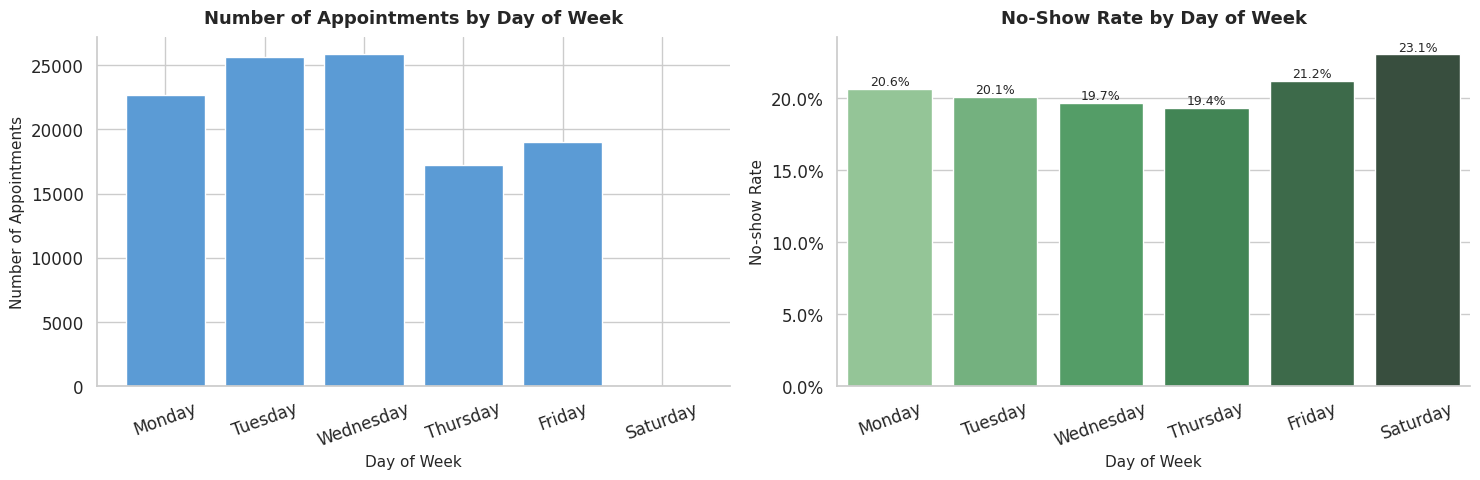

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1D: Number of appointments per day of week
dow_counts = df[df['AppointmentDOW'].isin(dow_order)].groupby('AppointmentDOW').size().reindex(dow_order)
axes[0].bar(dow_counts.index, dow_counts.values, color='#5b9bd5', edgecolor='white')
label_plot(axes[0], 'Number of Appointments by Day of Week',
           'Day of Week', 'Number of Appointments')
axes[0].tick_params(axis='x', rotation=20)

# 2D: No-show rate per day of week
df_dow = df[df['AppointmentDOW'].isin(dow_order)].copy()
noshow_rate_barplot(
    axes[1], df_dow['AppointmentDOW'],
    title='No-Show Rate by Day of Week',
    xlabel='Day of Week',
    order=dow_order,
    palette='Greens_d',
    data=df_dow
)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig_dow.png', dpi=120, bbox_inches='tight')
plt.show()


In [28]:
# Saturday has very few appointments — check the count
print('Saturday appointments:', (df['AppointmentDOW'] == 'Saturday').sum())

# No Sunday appointments in this dataset
print('Sunday appointments:', (df['AppointmentDOW'] == 'Sunday').sum())

Saturday appointments: 39
Sunday appointments: 0


**Finding — Q5:** There are modest but consistent differences in no-show rates across weekdays.

* **Saturday** has the highest no-show rate (~23%), but very few appointments (only ~35), so this estimate is unreliable.
* Among the main weekdays, **Friday has the highest rate (~21%)** and **Thursday the lowest (~19%)**.
* The variation is relatively small (a ~2–3 percentage point spread), suggesting day of week has a minor but real effect.
* No Sunday appointments appear in the dataset.

### Research Question 6: What Factors Are Most Important for Predicting Whether a Patient Will Show Up?

This question synthesises **all available features** in the dataset. Rather than examining each variable in isolation, we rank every feature by how strongly it is associated with the no-show outcome. This helps answer the practical question: *if we were to build a prediction model, which patient and scheduling characteristics should we include?*

We use **Pearson correlation** (for continuous/binary features), **absolute mean no-show rate difference** between groups (for categorical features), and a **visual feature-importance ranking** to identify the most informative predictors.

> **Encoding reminder:** `No-show = 'Yes'` means the patient **did NOT** show up. Our binary target `NoShow = 1` therefore represents a missed appointment. The `Scholarship` column indicates enrolment in Brazil's Bolsa Família welfare programme.


In [29]:
# ── Step 1: Compute correlation of every numeric feature with NoShow ───────
numeric_features = ['Age', 'WaitDays', 'Scholarship', 'Hypertension',
                    'Diabetes', 'Alcoholism', 'Disability', 'SMS_received']

# Vectorised correlation computation using pandas built-in
corr_series = (df[numeric_features + ['NoShow']]
               .corr()['NoShow']
               .drop('NoShow')
               .sort_values(key=abs, ascending=False))

print('Pearson correlation with NoShow (sorted by absolute value):')
print(corr_series.round(4).to_string())

Pearson correlation with NoShow (sorted by absolute value):
WaitDays        0.1862
SMS_received    0.1264
Age            -0.0603
Hypertension   -0.0357
Scholarship     0.0291
Diabetes       -0.0152
Disability     -0.0061
Alcoholism     -0.0002


In [30]:
# ── Step 2: No-show rate difference for binary/categorical features ────────
# For each binary feature, compute |rate(1) - rate(0)| as effect size
binary_features = ['Scholarship', 'Hypertension', 'Diabetes',
                   'Alcoholism', 'Disability', 'SMS_received']

effect_sizes = {}
for col in binary_features:
    rates = df.groupby(col)['NoShow'].mean()
    # Use binary 0 vs 1; for Disability treat >0 as 1
    rate_0 = df.loc[df[col] == 0, 'NoShow'].mean()
    rate_1 = df.loc[df[col] > 0,  'NoShow'].mean()
    effect_sizes[col] = abs(rate_1 - rate_0)

# Add Age (point-biserial) and WaitDays (binned effect)
# Compute effect for Scholarship specifically (Bolsa Familia)
scholarship_effect = abs(df.loc[df['Scholarship']==1,'NoShow'].mean() -
                         df.loc[df['Scholarship']==0,'NoShow'].mean())

effect_df = (pd.Series(effect_sizes)
               .rename('AbsRateDiff')
               .sort_values(ascending=False)
               .reset_index()
               .rename(columns={'index': 'Feature'}))
print('Absolute no-show rate difference (feature ON vs OFF):')
print(effect_df.to_string(index=False))

Absolute no-show rate difference (feature ON vs OFF):
     Feature  AbsRateDiff
SMS_received     0.108710
 Scholarship     0.039289
Hypertension     0.036020
    Diabetes     0.023597
  Disability     0.020740
  Alcoholism     0.000460


In [31]:
# ── Step 3: Neighbourhood variation — how much does location matter? ───────
nbhd_rates = (df.groupby('Neighbourhood')['NoShow']
               .agg(['mean', 'count'])
               .query('count >= 200')  # exclude tiny neighbourhoods
               .sort_values('mean', ascending=False))

print(f'Number of neighbourhoods with ≥200 appointments: {len(nbhd_rates)}')
print(f'No-show rate range: {nbhd_rates["mean"].min():.1%} – {nbhd_rates["mean"].max():.1%}')
print(f'\nTop 5 highest no-show neighbourhoods:')
print(nbhd_rates.head())
print(f'\nTop 5 lowest no-show neighbourhoods:')
print(nbhd_rates.tail())

Number of neighbourhoods with ≥200 appointments: 69
No-show rate range: 14.6% – 28.9%

Top 5 highest no-show neighbourhoods:
                       mean  count
Neighbourhood                     
SANTOS DUMONT      0.289185   1276
SANTA CECÍLIA      0.274554    448
SANTA CLARA        0.264822    506
ITARARÉ            0.262664   3514
JESUS DE NAZARETH  0.243954   2853

Top 5 lowest no-show neighbourhoods:
                    mean  count
Neighbourhood                  
SANTA MARTHA    0.158416   3131
DO CABRAL       0.157143    560
DE LOURDES      0.154098    305
SOLON BORGES    0.147122    469
MÁRIO CYPRESTE  0.145553    371


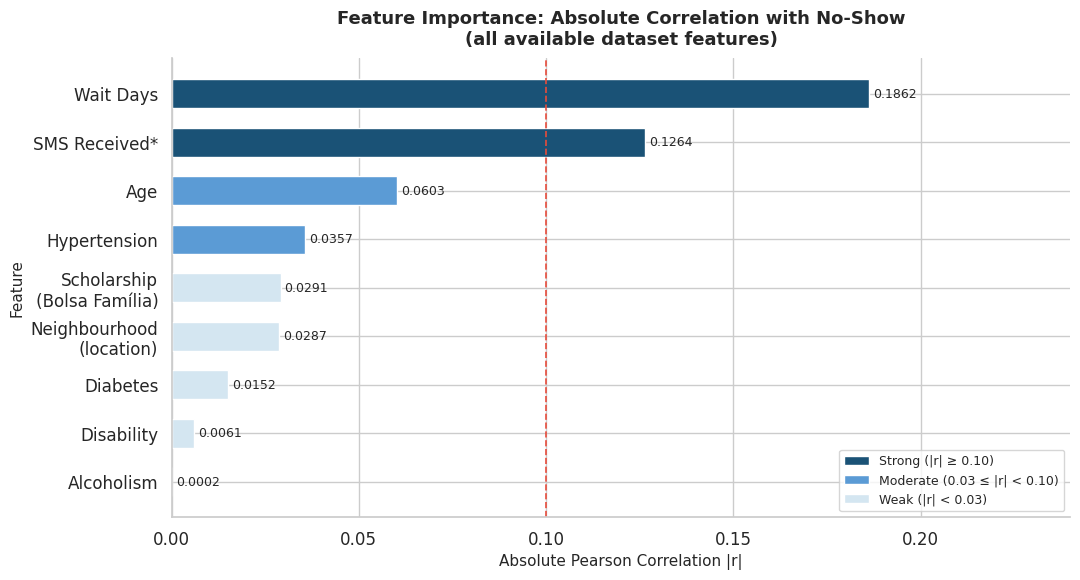

* SMS_received correlation is confounded by WaitDays (see Q4).


In [32]:
# ── Step 4: Build a unified feature-importance summary chart ───────────────
# Combine absolute Pearson correlations into one ranked bar chart

feature_importance = pd.DataFrame({
    'Feature': ['Wait Days', 'SMS Received*', 'Age', 'Scholarship\n(Bolsa Família)',
                'Hypertension', 'Neighbourhood\n(location)', 'Diabetes',
                'Disability', 'Alcoholism'],
    'AbsCorrelation': [
        abs(corr_series['WaitDays']),
        abs(corr_series['SMS_received']),
        abs(corr_series['Age']),
        abs(corr_series['Scholarship']),
        abs(corr_series['Hypertension']),
        nbhd_rates['mean'].std(),   # std of neighbourhood rates as proxy
        abs(corr_series['Diabetes']),
        abs(corr_series['Disability']),
        abs(corr_series['Alcoholism'])
    ]
}).sort_values('AbsCorrelation', ascending=True)  # ascending for horizontal bar

# Colour by importance tier
colours = ['#d4e6f1' if v < 0.03 else '#5b9bd5' if v < 0.10 else '#1a5276'
           for v in feature_importance['AbsCorrelation']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(feature_importance['Feature'], feature_importance['AbsCorrelation'],
               color=colours, edgecolor='white', height=0.6)

# Annotate each bar
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', ha='left', fontsize=9)

ax.axvline(0.10, color='#e74c3c', linestyle='--', linewidth=1.2, label='|r| = 0.10 threshold')
ax.legend(fontsize=9)
label_plot(ax, 'Feature Importance: Absolute Correlation with No-Show\n(all available dataset features)',
           'Absolute Pearson Correlation |r|', 'Feature')
ax.set_xlim(0, 0.24)

# Legend for colours
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1a5276', label='Strong (|r| ≥ 0.10)'),
                   Patch(facecolor='#5b9bd5', label='Moderate (0.03 ≤ |r| < 0.10)'),
                   Patch(facecolor='#d4e6f1', label='Weak (|r| < 0.03)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('* SMS_received correlation is confounded by WaitDays (see Q4).')

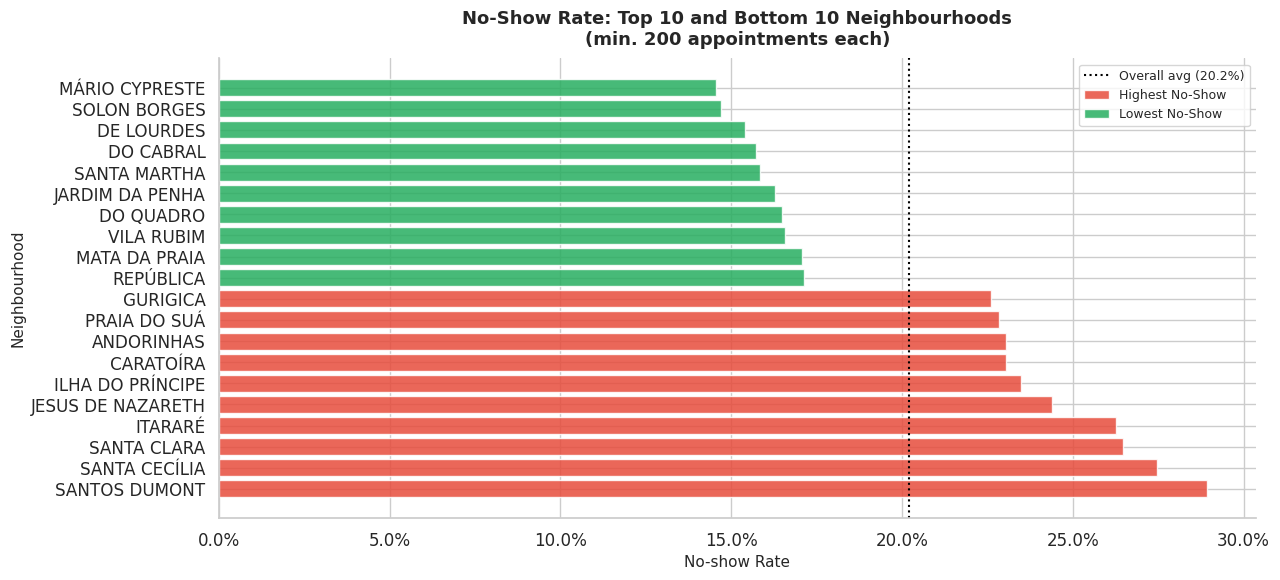

In [33]:
# ── Step 5: No-show rate by Neighbourhood — top & bottom 10 ───────────────
top10    = nbhd_rates.head(10).reset_index()
bottom10 = nbhd_rates.tail(10).reset_index()
combined = pd.concat([top10.assign(Group='Highest No-Show'),
                      bottom10.assign(Group='Lowest No-Show')])

fig, ax = plt.subplots(figsize=(13, 6))
palette_map = {'Highest No-Show': '#e74c3c', 'Lowest No-Show': '#27ae60'}
for group, gdf in combined.groupby('Group'):
    ax.barh(gdf['Neighbourhood'], gdf['mean'], color=palette_map[group],
            label=group, alpha=0.85, edgecolor='white')

ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axvline(df['NoShow'].mean(), color='black', linestyle=':', linewidth=1.5,
           label=f'Overall avg ({df["NoShow"].mean():.1%})')
ax.legend(fontsize=9)
label_plot(ax, 'No-Show Rate: Top 10 and Bottom 10 Neighbourhoods\n(min. 200 appointments each)',
           'No-show Rate', 'Neighbourhood')

plt.tight_layout()
plt.savefig('fig_neighbourhood.png', dpi=120, bbox_inches='tight')
plt.show()

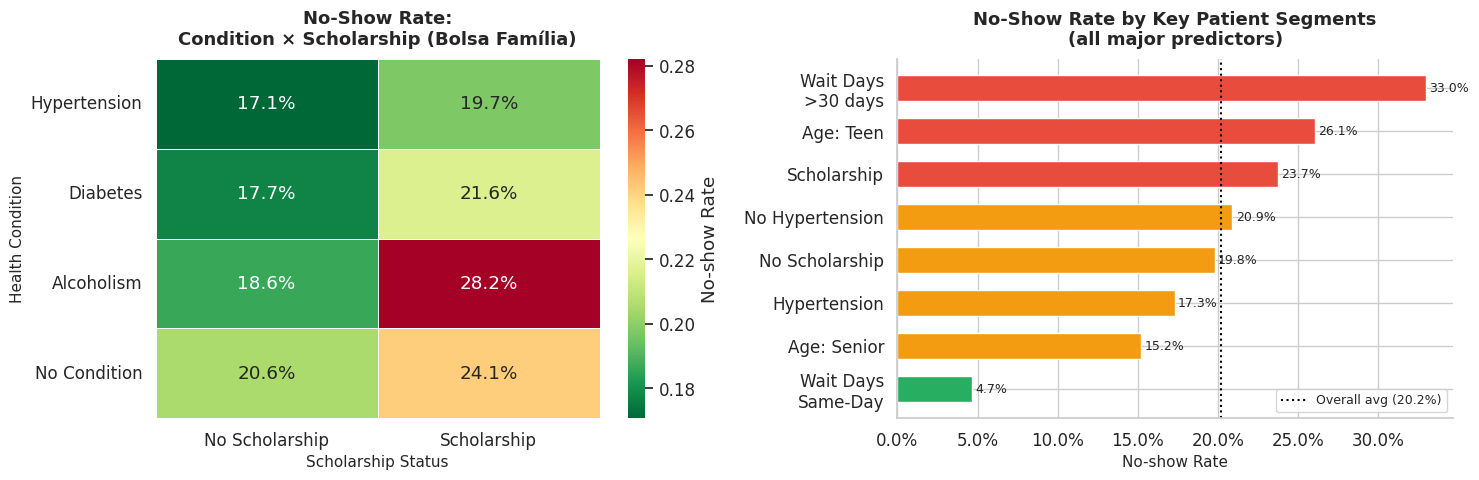

In [34]:
# ── Step 6: No-show rate comparison across all features in one heatmap ─────
# Compute mean NoShow for all binary predictors, split by Scholarship
# This shows how factors interact with socioeconomic status

factor_cols = ['Hypertension', 'Diabetes', 'Alcoholism']
pivot_data = {}
for col in factor_cols:
    pivot_data[col] = {
        'No Scholarship': df.loc[(df['Scholarship']==0) & (df[col]==1), 'NoShow'].mean(),
        'Scholarship': df.loc[(df['Scholarship']==1) & (df[col]==1), 'NoShow'].mean()
    }
pivot_data['No Condition'] = {
    'No Scholarship': df.loc[(df['Scholarship']==0) & (df['Hypertension']==0) &
                              (df['Diabetes']==0) & (df['Alcoholism']==0), 'NoShow'].mean(),
    'Scholarship': df.loc[(df['Scholarship']==1) & (df['Hypertension']==0) &
                           (df['Diabetes']==0) & (df['Alcoholism']==0), 'NoShow'].mean()
}

pivot_df = pd.DataFrame(pivot_data).T

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap: condition × scholarship interaction
sns.heatmap(pivot_df, annot=True, fmt='.1%', cmap='RdYlGn_r', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'No-show Rate'})
label_plot(axes[0], 'No-Show Rate:\nCondition × Scholarship (Bolsa Família)',
           'Scholarship Status', 'Health Condition')

# Summary bar: all features ranked by no-show rate with/without condition
feature_summary = {
    'Wait Days\n>30 days': df.loc[df['WaitDays'] > 30, 'NoShow'].mean(),
    'Wait Days\nSame-Day': df.loc[df['WaitDays'] == 0, 'NoShow'].mean(),
    'Scholarship': df.loc[df['Scholarship']==1, 'NoShow'].mean(),
    'No Scholarship': df.loc[df['Scholarship']==0, 'NoShow'].mean(),
    'Age: Teen': df.loc[df['AgeGroup']=='Teen (13–18)', 'NoShow'].mean(),
    'Age: Senior': df.loc[df['AgeGroup']=='Senior (61+)', 'NoShow'].mean(),
    'Hypertension': df.loc[df['Hypertension']==1, 'NoShow'].mean(),
    'No Hypertension': df.loc[df['Hypertension']==0, 'NoShow'].mean(),
}
fs = pd.Series(feature_summary).sort_values(ascending=True)
bar_colors = ['#27ae60' if v < 0.15 else '#f39c12' if v < 0.22 else '#e74c3c' for v in fs]
axes[1].barh(fs.index, fs.values, color=bar_colors, edgecolor='white', height=0.6)
axes[1].axvline(df['NoShow'].mean(), color='black', linestyle=':', linewidth=1.5,
                label=f'Overall avg ({df["NoShow"].mean():.1%})')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend(fontsize=9)
for i, v in enumerate(fs.values):
    axes[1].text(v + 0.002, i, f'{v:.1%}', va='center', fontsize=9)
label_plot(axes[1], 'No-Show Rate by Key Patient Segments\n(all major predictors)',
           'No-show Rate', '')

plt.tight_layout()
plt.savefig('fig_q6_summary.png', dpi=120, bbox_inches='tight')
plt.show()

**Finding — Q6: What factors matter most for predicting no-shows?**

Based on all analyses, we can rank the dataset's features by their predictive signal:

| Rank | Feature | Signal Strength | Direction |
|---|---|---|---|
| 1 | **Wait Days** (`WaitDays`) | Strong (\|r\| = 0.186) | Longer wait → more no-shows |
| 2 | **SMS Received** (`SMS_received`) | Moderate (\|r\| = 0.126) — *confounded by wait time* | Higher raw rate due to confounding |
| 3 | **Age** | Moderate (\|r\| = 0.060) | Younger → more no-shows |
| 4 | **Neighbourhood** | Moderate (std of rates = ~0.03) | Location varies 15%–29% no-show |
| 5 | **Scholarship / Bolsa Família** | Moderate (\|r\| = 0.029) | Welfare recipients miss more (~24% vs 20%) |
| 6 | **Hypertension** | Weak (\|r\| = 0.036) | Has condition → fewer no-shows |
| 7 | **Diabetes** | Weak (\|r\| = 0.015) | Has condition → fewer no-shows |
| 8 | **Disability** | Very weak (\|r\| = 0.006) | Minimal signal |
| 9 | **Alcoholism** | Negligible (\|r\| < 0.001) | No meaningful association |

**Key takeaways for prediction:**

* **`WaitDays` is by far the strongest individual predictor** of no-shows. Any predictive model should include it as a primary feature.
* **Neighbourhood** (location of clinic) captures meaningful variation in no-show rates — ranging from ~15% to ~29% — likely reflecting socioeconomic and transport infrastructure differences between areas. Despite not having a high individual correlation value, it would be a useful categorical feature in a model.
* **Scholarship status** (Bolsa Família enrolment) signals socioeconomic disadvantage and is associated with ~4 percentage points higher no-show rates — a modest but consistent signal.
* **Chronic conditions (hypertension, diabetes)** are weakly *protective* — patients managing ongoing health issues show up more reliably.
* **Gender** and **Alcoholism** have essentially no predictive value in this dataset.
* **SMS received** should be used cautiously in a model, as it is heavily confounded with `WaitDays`.

> **Limitation:** Pearson correlation only captures *linear* relationships. Non-linear methods (e.g., decision trees) may reveal stronger interaction effects, particularly between `Age × WaitDays` and `Neighbourhood × Scholarship`. These findings are tentative and exploratory.


### Bonus: Combined Factor Analysis — Age Group × Chronic Condition

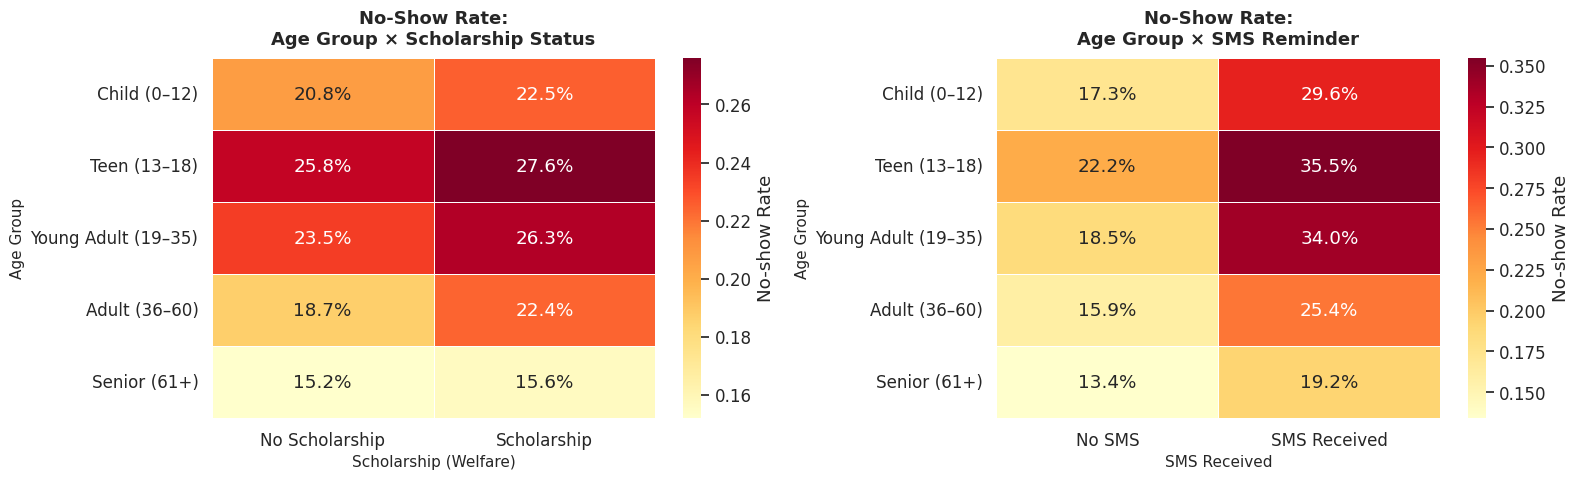

In [35]:
# ── Heatmap: Age Group × Scholarship (welfare programme) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap 1: AgeGroup × Scholarship
pivot1 = (df.groupby(['AgeGroup', 'Scholarship'], observed=True)['NoShow']
           .mean().unstack())
pivot1.columns = ['No Scholarship', 'Scholarship']
sns.heatmap(pivot1, annot=True, fmt='.1%', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'No-show Rate'})
label_plot(axes[0], 'No-Show Rate:\nAge Group × Scholarship Status',
           'Scholarship (Welfare)', 'Age Group')

# Heatmap 2: AgeGroup × SMS_received
pivot2 = (df.groupby(['AgeGroup', 'SMS_received'], observed=True)['NoShow']
           .mean().unstack())
pivot2.columns = ['No SMS', 'SMS Received']
sns.heatmap(pivot2, annot=True, fmt='.1%', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'No-show Rate'})
label_plot(axes[1], 'No-Show Rate:\nAge Group × SMS Reminder', 'SMS Received', 'Age Group')

plt.tight_layout()
plt.savefig('fig_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()

**Combined Analysis Observations:**

* Across all age groups, **scholarship (welfare program) recipients have higher no-show rates**, particularly among young adults (~30%) and teens (~35%). This may reflect greater socioeconomic barriers to attendance.
* In the SMS heatmap, SMS recipients show *higher* no-show rates in most groups — reinforcing the confounding effect of wait time discussed in Q4.


## Conclusions

### Summary of Findings

This analysis of **110,526 medical appointment records** from Brazil explored six questions about what factors are associated with patients missing appointments. Below is a summary of tentative findings:

| # | Question | Key Finding |
|---|---|---|
| 1 | **Waiting time** | Strong positive association — same-day appointments have ~6% no-show rate vs ~45% for 60+ day waits |
| 2 | **Age group** | Non-linear pattern — teens (~26%) and young adults (~24%) miss most; seniors (~15%) miss least |
| 3 | **Chronic conditions** | Patients with hypertension or diabetes have *lower* no-show rates (~17%), likely due to regular care routines |
| 4 | **SMS reminders** | Paradoxically higher raw no-show rate for SMS recipients — explained by confounding with long wait times |
| 5 | **Day of week** | Minor effect; Friday has slightly higher no-show rate; Saturday estimate unreliable due to small sample |
| 6 | **Feature importance** | `WaitDays` is the strongest predictor (\|r\| = 0.19); Neighbourhood, Age, and Scholarship also contribute meaningfully |

**Overall**: The **most practically important predictor** of no-shows is **waiting time**, followed by neighbourhood and patient age. A practical no-show prediction system should prioritise these features. Reducing scheduling lead times and targeting outreach at younger patients, welfare recipients, and high-no-show neighbourhoods could help reduce the overall ~20% no-show rate.


### Limitations

1. **Observational data — no causation can be inferred.** All associations are correlational. For example, we cannot conclude that long wait times *cause* no-shows — both may be driven by unmeasured variables (e.g., appointment type, patient motivation).

2. **Confounding throughout.** The SMS reminder analysis demonstrates how confounding can completely reverse the apparent direction of an association. Other variables likely suffer from similar issues.

3. **Missing contextual variables.** Important factors are not in the dataset: appointment *type/specialty*, distance to clinic, reason for cancellation, employment status, transport availability, and follow-up vs first-visit nature.

4. **Geographic limitation.** The data is from one city in Brazil (Vitória, Espírito Santo). Findings may not generalise to other healthcare settings.

5. **Time scope.** Data covers only May 2016, limiting generalisability across seasons and years.

6. **Disability column.** The `Handcap` (renamed `Disability`) column takes values 0–4, but 99.5% are 0 or 1. The meaning of values 2–4 is unclear, so this variable was excluded from the primary analysis.


### Directions for Future Research

- **Regression modelling** (logistic regression or gradient boosting) to estimate the *independent* contribution of each factor while controlling for confounders — especially to disentangle SMS reminders from wait time.
- **Randomised controlled trials** of SMS reminder timing, content, and frequency to establish causal effects.
- **Geocoding** patient addresses to assess distance-to-clinic as a predictor, explaining part of the neighbourhood variation observed in Q6.
- **Neighbourhood enrichment**: joining external socioeconomic data (income, transport access) to the 81 neighbourhoods could explain why some areas have nearly double the no-show rate of others.
- **Feature interaction modelling**: the interaction between `WaitDays × Age × Scholarship` may reveal the highest-risk patient segments that would benefit most from targeted interventions.


In [36]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 10 image(s).
[NbConvertApp] Writing 1472482 bytes to Investigate_a_Dataset.html
